2026-04-09 05:58:18.513158: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 05:58:18.561897: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775685498.597612   27549 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775685498.610612   27549 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 05:58:18.672218: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr


🌊 Entering Market Scenario: Liquid Blue-Chip
>>> Training PPO Agent (Increased to 100k steps for convergence)...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn

>>> Running Backtest...

🌊 Entering Market Scenario: Normal Market
>>> Training PPO Agent (Increased to 100k steps for convergence)...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


>>> Running Backtest...

🌊 Entering Market Scenario: Illiquid Penny Stock
>>> Training PPO Agent (Increased to 100k steps for convergence)...
>>> Running Backtest...


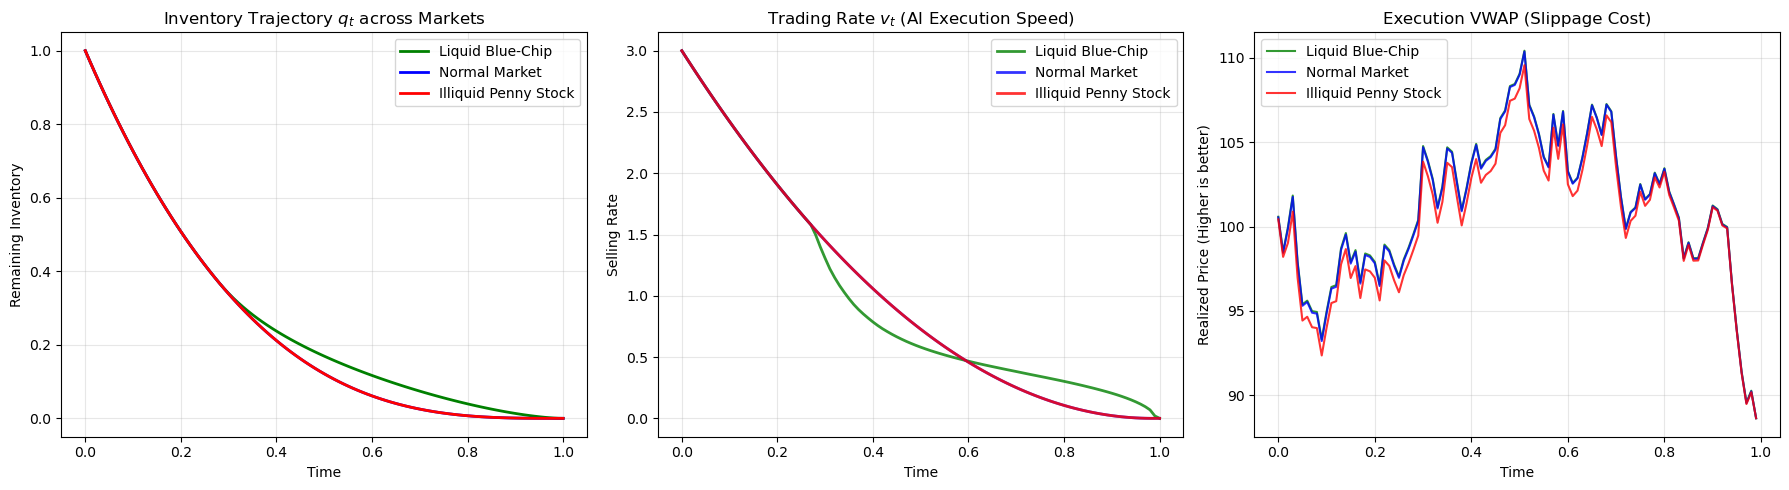

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from stable_baselines3 import PPO

# Ensure the LOB environment can be imported
sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env_lob import LiquidationEnvLOB

scenarios = {
    "A_Blue_Chip": {
        "name": "Liquid Blue-Chip",
        "params": {"tick_size": 0.01, "base_vol": 0.10, "kappa": 50.0},
        "color": "green",
    },
    "B_Normal_Market": {
        "name": "Normal Market",
        "params": {"tick_size": 0.05, "base_vol": 0.05, "kappa": 10.0},
        "color": "blue",
    },
    "C_Penny_Stock": {
        "name": "Illiquid Penny Stock",
        "params": {"tick_size": 0.10, "base_vol": 0.01, "kappa": 2.0},
        "color": "red",
    }
}

results = {}
# =====================================================================
# 核心修复：提前生成一条固定的 100 步价格路径 (z_path)
# =====================================================================
rng = np.random.default_rng(42) # 使用固定种子保证每次跑图一样
fixed_z_path = rng.normal(size=100) 

for key, scenario in scenarios.items():
    print(f"\n{'='*60}")
    print(f"🌊 Entering Market Scenario: {scenario['name']}")
    print(f"{'='*60}")
    
    env = LiquidationEnvLOB(
        **scenario["params"], 
        T=1.0, q0=1.0, S0=100.0, sigma=0.2, lam=0.5, N=100
    )
    
    print(">>> Training PPO Agent (Increased to 100k steps for convergence)...")
    model = PPO("MlpPolicy", env, verbose=0, learning_rate=3e-4, n_steps=512)
    # 提高训练步数消除蓝线的抖动噪音
    model.learn(total_timesteps=100000)
    
    print(">>> Running Backtest...")
    # 核心修复：把固定的 z_path 传给环境，确保大家经历完全一样的牛熊市！
    obs, _ = env.reset(z_path=fixed_z_path)
    q_path, v_path, vwap_path = [env.q0], [], []
    done = False
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, term, trunc, info = env.step(action)
        
        q_path.append(info["inventory"])
        v_path.append(info["execution_rate"])
        vwap_path.append(info["vwap"])
        done = term or trunc
        
    v_path.append(0) 
    results[key] = {
        "q": q_path, "v": v_path, "vwap": vwap_path,
        "color": scenario["color"], "label": scenario["name"]
    }

time_axis = np.linspace(0, 1.0, 101)
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for key, res in results.items():
    axs[0].plot(time_axis, res["q"], color=res["color"], label=res["label"], linewidth=2)
    axs[1].plot(time_axis, res["v"], color=res["color"], label=res["label"], linewidth=2, alpha=0.8)
    axs[2].plot(time_axis[:-1], res["vwap"], color=res["color"], label=res["label"], linewidth=1.5, alpha=0.8)

axs[0].set_title("Inventory Trajectory $q_t$ across Markets")
axs[0].set_ylabel("Remaining Inventory")
axs[0].legend()

axs[1].set_title("Trading Rate $v_t$ (AI Execution Speed)")
axs[1].set_ylabel("Selling Rate")
axs[1].legend()

axs[2].set_title("Execution VWAP (Slippage Cost)")
axs[2].set_ylabel("Realized Price (Higher is better)")
axs[2].legend()

for ax in axs:
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("lob_scenario_analysis_english.png", dpi=300)
plt.show()

🚀 Initiating Final Showdown: MLP vs LSTM in Illiquid LOB

>>> [1/2] Training MLP Agent...

>>> [2/2] Training LSTM Agent (RecurrentPPO)...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/utils.py:168: UserWarning: get_schedule_fn() is deprecated, please use FloatSchedule() instead
  warnings.warn("get_schedule_fn() is deprecated, please use FloatSchedule() instead")
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/utils.py:214: UserWarning: constant_fn() is deprecated, please use ConstantSchedule() instead
  warnings.warn("constant_fn() is deprecated, please use ConstantSchedule() instead")



>>> Generating evaluation metrics...


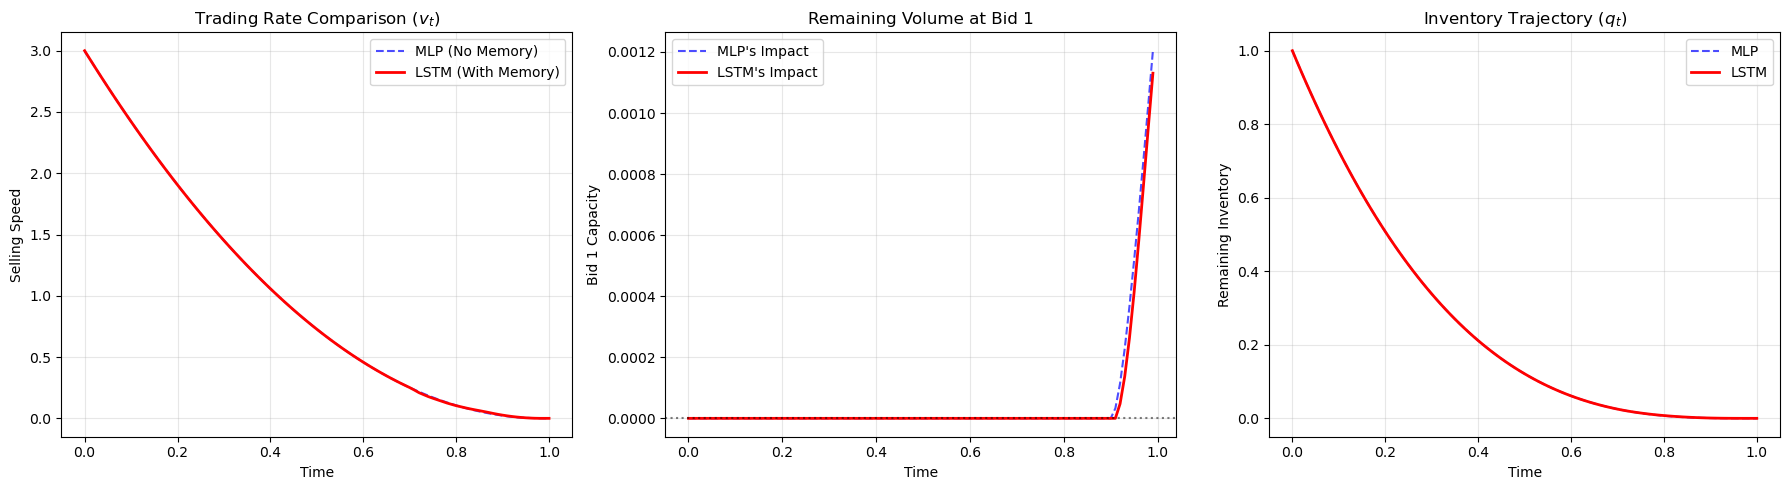

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO

sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env_lob import LiquidationEnvLOB

print("="*60)
print("🚀 Initiating Final Showdown: MLP vs LSTM in Illiquid LOB")
print("="*60)

# =====================================================================
# 1. Setup the most challenging battlefield: Illiquid Market
# =====================================================================
env_kwargs = {
    "tick_size": 0.10,  
    "base_vol": 0.01,   
    "kappa": 2.0,       
    "T": 1.0, "q0": 1.0, "S0": 100.0, "sigma": 0.2, "lam": 0.5, "N": 100
}

env_train = LiquidationEnvLOB(**env_kwargs)

# =====================================================================
# 2. Train MLP (No Memory)
# =====================================================================
print("\n>>> [1/2] Training MLP Agent...")
model_mlp = PPO("MlpPolicy", env_train, verbose=0, learning_rate=3e-4, n_steps=512)
model_mlp.learn(total_timesteps=100000) 

# =====================================================================
# 3. Train LSTM (With Time-Series Memory)
# =====================================================================
print("\n>>> [2/2] Training LSTM Agent (RecurrentPPO)...")
model_lstm = RecurrentPPO("MlpLstmPolicy", env_train, verbose=0, learning_rate=3e-4, n_steps=512,
                          policy_kwargs=dict(lstm_hidden_size=64))
model_lstm.learn(total_timesteps=100000)

# =====================================================================
# 4. Head-to-Head Backtest (STRICTLY CONTROLLED ENVIRONMENT)
# =====================================================================
print("\n>>> Generating evaluation metrics...")
env_eval = LiquidationEnvLOB(**env_kwargs)

# 【核心修复】：生成一条绝对固定的价格冲击路径，让双方在同一个平行宇宙对决！
rng = np.random.default_rng(2026)
fixed_z_path = rng.normal(size=100)

# --- Run MLP ---
# 注入固定路径 z_path
obs, _ = env_eval.reset(z_path=fixed_z_path)
q_mlp, v_mlp, bid_mlp = [env_eval.q0], [], []
done = False
while not done:
    action, _ = model_mlp.predict(obs, deterministic=True)
    obs, _, term, trunc, info = env_eval.step(action)
    q_mlp.append(info["inventory"])
    v_mlp.append(info["execution_rate"])
    bid_mlp.append(info["bid1_vol"]) 
    done = term or trunc

# --- Run LSTM ---
# 再次注入同一条路径 fixed_z_path，确保绝对公平！
obs, _ = env_eval.reset(z_path=fixed_z_path) 
q_lstm, v_lstm, bid_lstm = [env_eval.q0], [], []
lstm_states = None
episode_starts = np.ones((1,), dtype=bool)
done = False

while not done:
    action, lstm_states = model_lstm.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
    obs, _, term, trunc, info = env_eval.step(action)
    q_lstm.append(info["inventory"])
    v_lstm.append(info["execution_rate"])
    bid_lstm.append(info["bid1_vol"])
    episode_starts = np.array([False])
    done = term or trunc

v_mlp.append(0); v_lstm.append(0)

# =====================================================================
# 5. Plotting the Showdown
# =====================================================================
time_axis = np.linspace(0, 1.0, 101)

fig, axs = plt.subplots(1, 3, figsize=(18, 5))

# 图 1：交易速率
axs[0].plot(time_axis, v_mlp, label="MLP (No Memory)", linestyle='--', color='blue', alpha=0.7)
axs[0].plot(time_axis, v_lstm, label="LSTM (With Memory)", linewidth=2, color='red')
axs[0].set_title("Trading Rate Comparison ($v_t$)")
axs[0].set_ylabel("Selling Speed")
axs[0].legend()

# 图 2：买一档盘口剩余量
axs[1].plot(time_axis[:-1], bid_mlp, label="MLP's Impact", linestyle='--', color='blue', alpha=0.7)
axs[1].plot(time_axis[:-1], bid_lstm, label="LSTM's Impact", linewidth=2, color='red')
axs[1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
axs[1].set_title("Remaining Volume at Bid 1")
axs[1].set_ylabel("Bid 1 Capacity")
axs[1].legend()

# 图 3：库存消耗轨迹
axs[2].plot(time_axis, q_mlp, label="MLP", linestyle='--', color='blue', alpha=0.7)
axs[2].plot(time_axis, q_lstm, label="LSTM", linewidth=2, color='red')
axs[2].set_title("Inventory Trajectory ($q_t$)")
axs[2].set_ylabel("Remaining Inventory")
axs[2].legend()

for ax in axs:
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("ultimate_lob_showdown_english.png", dpi=300)
plt.show()

2026-04-09 08:39:37.989503: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-09 08:39:38.090235: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775695178.115527   66153 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775695178.126451   66153 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-09 08:39:38.244601: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

🚀 The Ultimate 2x2 Matrix (With Auto Save/Load)

[Liquid Market] Initializing environments...
[Liquid Market] 📂 Found saved MLP model. Loading...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/on_policy_algorithm.py:150: UserWarning: You are trying to run PPO on the GPU, but it is primarily intended to run on the CPU when not using a CNN policy (you are using ActorCriticPolicy which should be a MlpPolicy). See https://github.com/DLR-RM/stable-baselines3/issues/1245 for more info. You can pass `device='cpu'` or `export CUDA_VISIBLE_DEVICES=` to force using the CPU.Note: The model will train, but the GPU utilization will be poor and the training might take longer than on CPU.
  warnings.warn

[Liquid Market] 📂 Found saved LSTM model. Loading...

[Illiquid Market] Initializing environments...
[Illiquid Market] 📂 Found saved MLP model. Loading...
[Illiquid Market] ⚙️ Training LSTM (100k steps, this may take a while)...


/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:235: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/gymnasium/spaces/box.py:305: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(
/home/koro/anaconda3/envs/finrl/lib/python3.9/site-packages/stable_baselines3/common/utils.py:214: UserWarning: constant_fn() is deprecated, please use ConstantSchedule() instead
  warnings.warn("constant_fn() is deprecated, please use ConstantSchedule() instead")


[Illiquid Market] ✅ LSTM Model saved successfully!


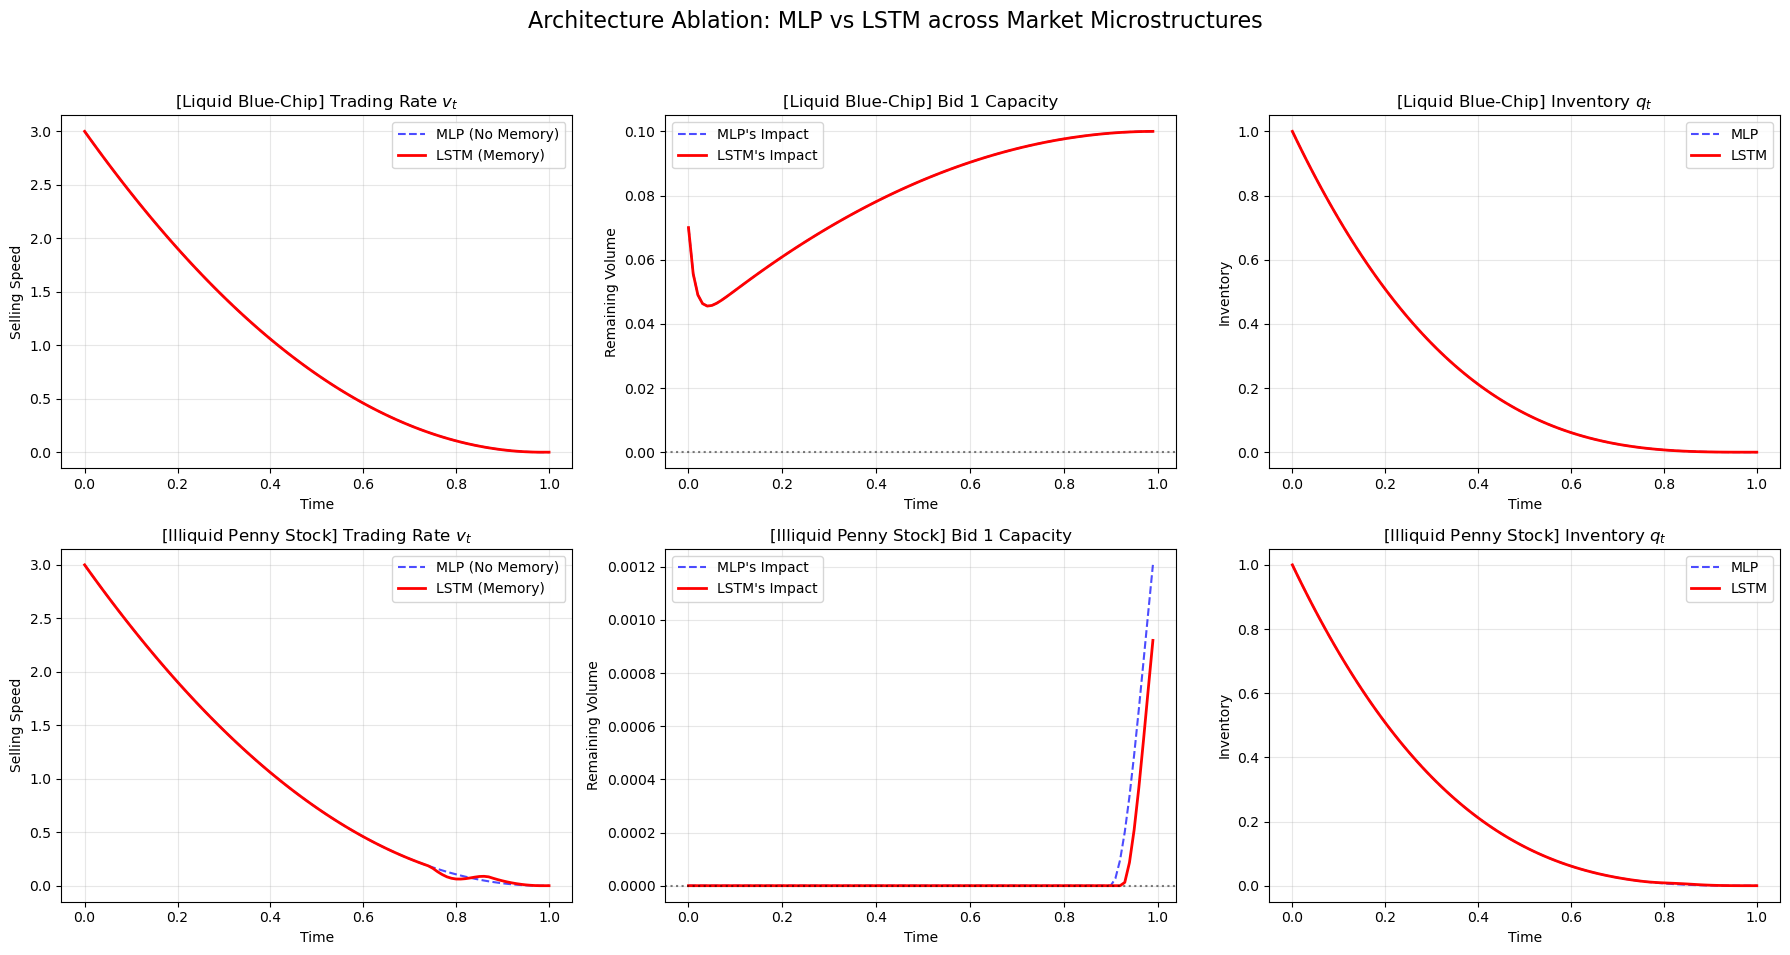

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from stable_baselines3 import PPO
from sb3_contrib import RecurrentPPO

sys.path.append(os.path.abspath('..'))
from Environment.liquidation_env_lob import LiquidationEnvLOB

print("="*60)
print("🚀 The Ultimate 2x2 Matrix (With Auto Save/Load)")
print("="*60)

# =====================================================================
# 1. 定义两个极端的市场环境
# =====================================================================
env_liquid_kwargs = {"tick_size": 0.01, "base_vol": 0.10, "kappa": 50.0, "T": 1.0, "q0": 1.0, "S0": 100.0, "sigma": 0.2, "lam": 0.5, "N": 100}
env_illiquid_kwargs = {"tick_size": 0.10, "base_vol": 0.01, "kappa": 2.0, "T": 1.0, "q0": 1.0, "S0": 100.0, "sigma": 0.2, "lam": 0.5, "N": 100}

# =====================================================================
# 2. 带有自动存档/读档功能的训练与测试循环
# =====================================================================
def train_and_evaluate(env_kwargs, market_name):
    print(f"\n[{market_name}] Initializing environments...")
    env_train = LiquidationEnvLOB(**env_kwargs)
    env_eval = LiquidationEnvLOB(**env_kwargs)
    
    # 创建存档文件夹
    save_dir = "./saved_models"
    os.makedirs(save_dir, exist_ok=True)
    
    # 市场名称转换成文件名格式
    safe_name = market_name.replace(' ', '_').lower()
    mlp_path = os.path.join(save_dir, f"ppo_mlp_{safe_name}")
    lstm_path = os.path.join(save_dir, f"ppo_lstm_{safe_name}")
    
    # ------------------ 处理 MLP ------------------
    if os.path.exists(mlp_path + ".zip"):
        print(f"[{market_name}] 📂 Found saved MLP model. Loading...")
        model_mlp = PPO.load(mlp_path)
    else:
        print(f"[{market_name}] ⚙️ Training MLP (100k steps)...")
        model_mlp = PPO("MlpPolicy", env_train, verbose=0, learning_rate=3e-4, n_steps=512)
        model_mlp.learn(total_timesteps=100000)
        model_mlp.save(mlp_path)
        print(f"[{market_name}] ✅ MLP Model saved successfully!")
    
    # ------------------ 处理 LSTM ------------------
    if os.path.exists(lstm_path + ".zip"):
        print(f"[{market_name}] 📂 Found saved LSTM model. Loading...")
        model_lstm = RecurrentPPO.load(lstm_path)
    else:
        print(f"[{market_name}] ⚙️ Training LSTM (100k steps, this may take a while)...")
        model_lstm = RecurrentPPO("MlpLstmPolicy", env_train, verbose=0, learning_rate=3e-4, n_steps=512, policy_kwargs=dict(lstm_hidden_size=64))
        model_lstm.learn(total_timesteps=100000)
        model_lstm.save(lstm_path)
        print(f"[{market_name}] ✅ LSTM Model saved successfully!")
    
    # ------------------ 强制公平回测 ------------------
    rng = np.random.default_rng(2026)
    fixed_z_path = rng.normal(size=100)
    
    # Eval MLP
    obs, _ = env_eval.reset(z_path=fixed_z_path)
    q_mlp, v_mlp, bid_mlp = [env_eval.q0], [], []
    done = False
    while not done:
        action, _ = model_mlp.predict(obs, deterministic=True)
        obs, _, term, trunc, info = env_eval.step(action)
        q_mlp.append(info["inventory"])
        v_mlp.append(info["execution_rate"])
        bid_mlp.append(info["bid1_vol"])
        done = term or trunc
        
    # Eval LSTM
    obs, _ = env_eval.reset(z_path=fixed_z_path)
    q_lstm, v_lstm, bid_lstm = [env_eval.q0], [], []
    lstm_states = None
    episode_starts = np.ones((1,), dtype=bool)
    done = False
    while not done:
        action, lstm_states = model_lstm.predict(obs, state=lstm_states, episode_start=episode_starts, deterministic=True)
        obs, _, term, trunc, info = env_eval.step(action)
        q_lstm.append(info["inventory"])
        v_lstm.append(info["execution_rate"])
        bid_lstm.append(info["bid1_vol"])
        episode_starts = np.array([False])
        done = term or trunc

    v_mlp.append(0); v_lstm.append(0)
    return {"q_mlp": q_mlp, "v_mlp": v_mlp, "bid_mlp": bid_mlp, 
            "q_lstm": q_lstm, "v_lstm": v_lstm, "bid_lstm": bid_lstm}

# =====================================================================
# 3. 执行训练与回测
# =====================================================================
res_liquid = train_and_evaluate(env_liquid_kwargs, "Liquid Market")
res_illiquid = train_and_evaluate(env_illiquid_kwargs, "Illiquid Market")

# =====================================================================
# 4. 绘制 2x2 矩阵图
# =====================================================================
time_axis = np.linspace(0, 1.0, 101)
fig, axs = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Architecture Ablation: MLP vs LSTM across Market Microstructures", fontsize=16)

def plot_row(row_idx, res_dict, market_title):
    # Trading Rate
    axs[row_idx, 0].plot(time_axis, res_dict["v_mlp"], label="MLP (No Memory)", linestyle='--', color='blue', alpha=0.7)
    axs[row_idx, 0].plot(time_axis, res_dict["v_lstm"], label="LSTM (Memory)", linewidth=2, color='red')
    axs[row_idx, 0].set_title(f"[{market_title}] Trading Rate $v_t$")
    axs[row_idx, 0].set_ylabel("Selling Speed")
    axs[row_idx, 0].legend()

    # Bid 1 Volume
    axs[row_idx, 1].plot(time_axis[:-1], res_dict["bid_mlp"], label="MLP's Impact", linestyle='--', color='blue', alpha=0.7)
    axs[row_idx, 1].plot(time_axis[:-1], res_dict["bid_lstm"], label="LSTM's Impact", linewidth=2, color='red')
    axs[row_idx, 1].axhline(y=0, color='black', linestyle=':', alpha=0.5)
    axs[row_idx, 1].set_title(f"[{market_title}] Bid 1 Capacity")
    axs[row_idx, 1].set_ylabel("Remaining Volume")
    axs[row_idx, 1].legend()

    # Inventory
    axs[row_idx, 2].plot(time_axis, res_dict["q_mlp"], label="MLP", linestyle='--', color='blue', alpha=0.7)
    axs[row_idx, 2].plot(time_axis, res_dict["q_lstm"], label="LSTM", linewidth=2, color='red')
    axs[row_idx, 2].set_title(f"[{market_title}] Inventory $q_t$")
    axs[row_idx, 2].set_ylabel("Inventory")
    axs[row_idx, 2].legend()

plot_row(0, res_liquid, "Liquid Blue-Chip")
plot_row(1, res_illiquid, "Illiquid Penny Stock")

for ax in axs.flat:
    ax.set_xlabel("Time")
    ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("comprehensive_ablation_matrix.png", dpi=300)
plt.show()